# Breast Cancer Type Prediction Using Gene Expression 

## Importing Libraries and Loading Datasets


In [1]:
import pandas as pd
import numpy as np

In [2]:
#https://www.kaggle.com/datasets/brunogrisci/breast-cancer-gene-expression-cumida/data
df=pd.read_csv("Breast_GSE45827.csv")

In [3]:
df.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


## Pre-processing and Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Columns: 54677 entries, samples to AFFX-TrpnX-M_at
dtypes: float64(54675), int64(1), object(1)
memory usage: 63.0+ MB


In [5]:
df.isnull().sum()

samples            0
type               0
1007_s_at          0
1053_at            0
117_at             0
                  ..
AFFX-ThrX-5_at     0
AFFX-ThrX-M_at     0
AFFX-TrpnX-3_at    0
AFFX-TrpnX-5_at    0
AFFX-TrpnX-M_at    0
Length: 54677, dtype: int64

In [6]:
#dropping irrelevant column
df.drop("samples", axis=1, inplace=True)

In [7]:
df.head()

,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,8.870780,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,7.767646,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,9.417956,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,9.022345,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,9.400056,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


## Data Visualization and Encoding

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [9]:
#setting theme
sns.set_theme()

<Axes: xlabel='type', ylabel='count'>

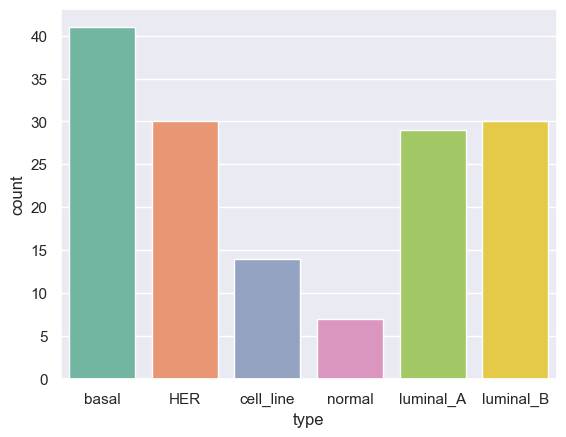

In [11]:
#creating counplot with breast cancer type
sns.countplot(df, x="type", hue="type", palette="Set2")

In [12]:
#labelling target 
le=LabelEncoder()
df["type"]=le.fit_transform(df["type"])

In [13]:
for i, x in enumerate(le.classes_):
    print(f"{i}, {x}")

0, HER
1, basal
2, cell_line
3, luminal_A
4, luminal_B
5, normal


In [14]:
#select features(X) and target(y)
y=df["type"]
X=df.drop("type", axis=1)

### Principle Component Analysis

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [16]:
X_pca = pd.DataFrame(data = X_pca)
X_pca.columns = ["PC_1","PC_2"]
X_pca["type"]=y

In [17]:
label_map = {0: "HER",
1: "basal",
2: "cell_line",
3: "luminal_A",
4: "luminal_B",
5: "normal"}

X_pca["type"] = X_pca["type"].replace(label_map)

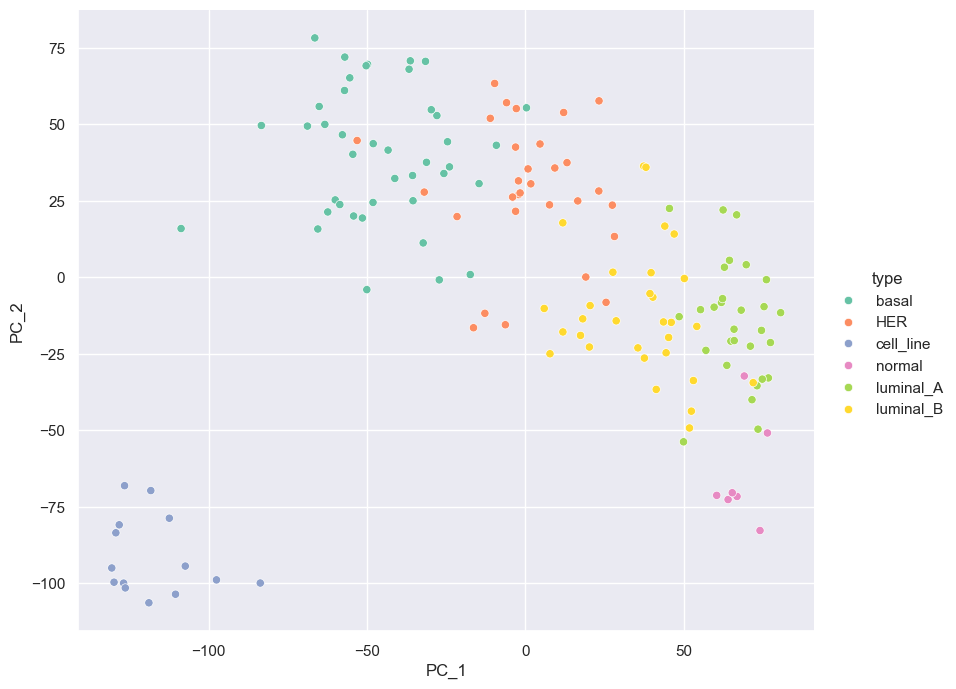

In [18]:
sns.pairplot(X_pca, x_vars="PC_1", y_vars="PC_2", hue="type", palette="Set2", height=7,aspect=1.2)
plt.show()

### T-SNE reduction

In [19]:
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X)
X_tsne = pd.DataFrame(data = X_tsne, columns=["TSNE1", "TSNE2"])
X_tsne["type"] = y
X_tsne["type"] = X_tsne["type"].replace(label_map)

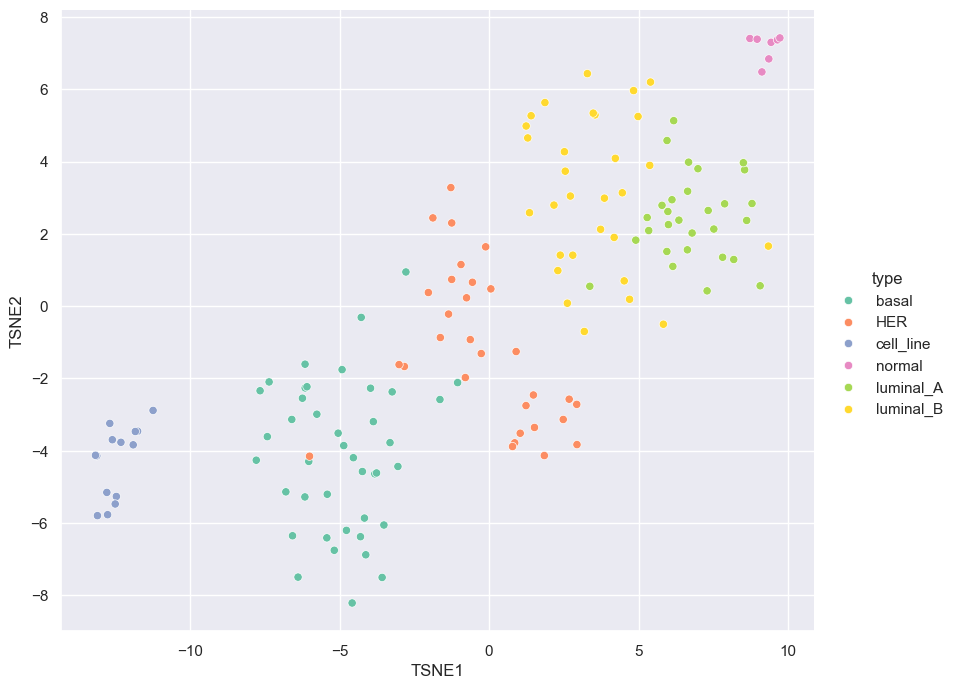

In [20]:
sns.pairplot(x_vars="TSNE1", y_vars="TSNE2", data=X_tsne, hue="type", palette="Set2", height=7,aspect=1.2)
plt.show()

## Preparing Data Before Training

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

In [22]:
#scaling data
ss=StandardScaler()
X_scaled=ss.fit_transform(X)

#splitting data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42, train_size=0.7)

## Model Training and Performance Assesing

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

### Baseline model: Random Forest, KNeighbors, SVM and XGBoost Classifier with all features

In [24]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Kneighbors": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": xgb.XGBClassifier()
}

In [25]:
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f'{model_name} Model')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    
    print('-'*40)

Random Forest Model
Accuracy: 0.8913043478260869
----------------------------------------
Kneighbors Model
Accuracy: 0.7391304347826086
----------------------------------------
SVM Model
Accuracy: 0.8478260869565217
----------------------------------------
XGBoost Model
Accuracy: 0.8695652173913043
----------------------------------------


### Feature Selection with Mutual Information

In [26]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train, y_train)
mi

array([0.13833546, 0.75554276, 0.21096   , ..., 0.03549412, 0.08501684,
       0.02239368])

In [27]:
#select top 500 features
n_features = 500
selected_scores_indices = np.argsort(mi)[::-1][0:n_features]

In [28]:
# get selected features
X_train_selected = X_train[:,selected_scores_indices]
X_test_selected = X_test[:,selected_scores_indices]

In [29]:
#model training with feature selection
for model_name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    print(f'{model_name} Model')
    print('Accuracy:', accuracy_score(y_test, y_pred))

    print('-'*40)

Random Forest Model
Accuracy: 0.9347826086956522
----------------------------------------
Kneighbors Model
Accuracy: 0.8913043478260869
----------------------------------------
SVM Model
Accuracy: 0.9347826086956522
----------------------------------------
XGBoost Model
Accuracy: 0.8913043478260869
----------------------------------------
